In [ ]:
# Setting up
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import Normalize
from matplotlib import cm
from matplotlib.legend_handler import HandlerBase
import numpy as np
import pandas as pd
import random


import scipy
import sys
import os
sys.path.insert(1, '../scripts/03_analytical_prediction')
from tpc_functions_oo import *
tpc_object = tpc_functions()


import tskit
from matplotlib.lines import Line2D
datadir = "../data/"

# Track data files that are used for figures and write their paths to a text file at the end
_accessed = set()
def _track(fn):
    def wrapped(path, *a, **k):
        _accessed.add(os.path.abspath(path))
        return fn(path, *a, **k)
    return wrapped
pd.read_csv = _track(pd.read_csv)
np.load     = _track(np.load)
tskit.load  = _track(tskit.load)

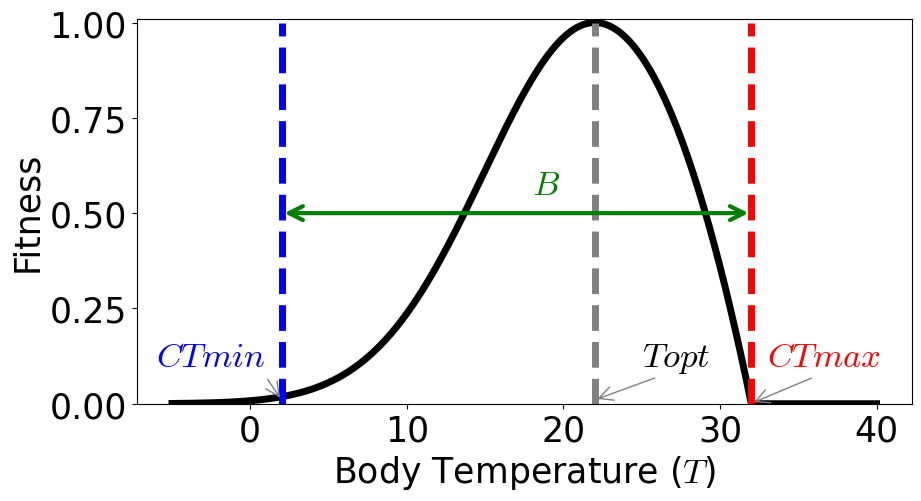

In [ ]:
# Figure 1A
Tlist = np.linspace(-5, 40, 400)
CTmin_example = 2
B_example = 30
w_enzymatic_example = tpc_object.w_enzymatic(CTmin=CTmin_example, B=B_example, T=Tlist)
w_tpc_example = tpc_object.w_TPC(CTmin=CTmin_example, B=B_example, T=Tlist)
CTmax_example = CTmin_example + B_example
Topt_example = CTmin_example + 2/3 * B_example

plt.rcParams.update({'font.size': 25})
plt.rcParams['mathtext.fontset'] = 'cm'
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(Tlist, w_enzymatic_example, linewidth=5, color='k')
ax.set_ylim(0, 1.01)
ax.set_xlabel(r"Body Temperature ($T$)")
ax.set_ylabel("Fitness")
ax.vlines(CTmin_example, ymin=0, ymax=1, linewidth=5, color='b', linestyle='--')
ax.text(-6, 0.1, r"$CTmin$", color='b')
ax.annotate("", xytext=(CTmin_example -1, 0.07), xy=(CTmin_example, 0.01),
            arrowprops=dict(arrowstyle="->", color="grey"))
ax.text(18, 0.55, r"$B$", color='g')
ax.annotate("", xytext=(CTmin_example, 0.5), xy=(CTmin_example + B_example, 0.5),
            arrowprops=dict(arrowstyle="<->", color="g", linewidth=3))
ax.text(25, 0.1, r"$Topt$")
ax.vlines(CTmin_example + 2/3 * B_example, ymin=0, ymax=1, linewidth=5, color='grey', linestyle='--')
ax.annotate("", xytext=(Topt_example+4, 0.07), xy=(Topt_example, 0.01),
            arrowprops=dict(arrowstyle="->", color="grey"))

ax.text(33, 0.1, r"$CTmax$", color='r')
ax.vlines(CTmax_example, ymin=0, ymax=1, linewidth=5, color='r', linestyle='--')
ax.annotate("", xytext=(CTmin_example+B_example+4, 0.07), xy=(CTmin_example+B_example, 0.001),
            arrowprops=dict(arrowstyle="->", color="grey"))
plt.savefig(f"../figures/Fig1a_TPC_components_labeled.png", bbox_inches="tight")

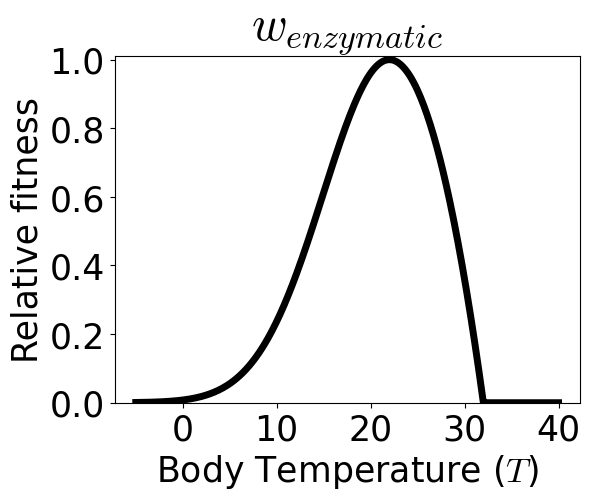

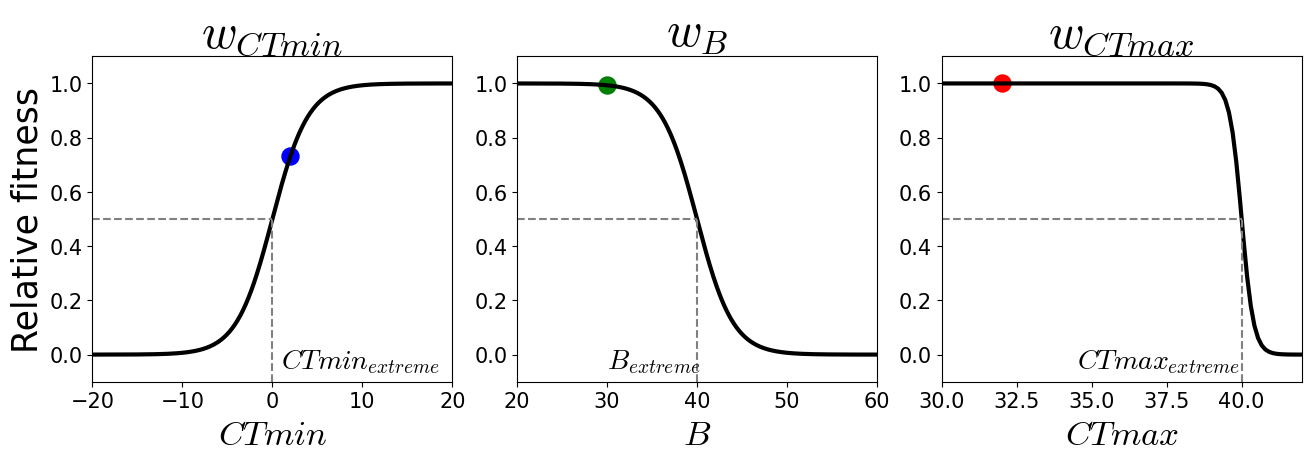

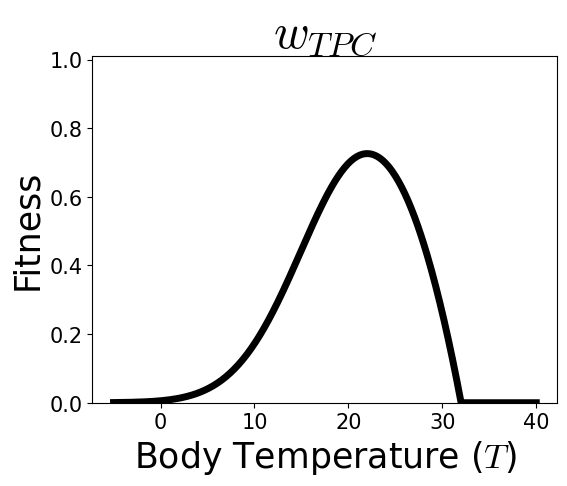

In [ ]:
# Figure 1B
fig, ax = plt.subplots(figsize=(6,4.5))
T_example = 20

ax.plot(Tlist, w_enzymatic_example, linewidth=5, color='k')
ax.set_ylim(0, 1.01)
ax.set_xlabel(r"Body Temperature ($T$)")
ax.set_ylabel("Relative fitness")
ax.set_title(r"$w_{enzymatic}$", fontweight='bold', fontsize=35)
fig.savefig("../figures/Fig1b_w_enzymatic.png", bbox_inches="tight")

plt.rcParams.update({'font.size': 15})
B_max = 40
DeltaB = 2
CTmin_min = 0
DeltaCTmin = 2
CTmax_max = 40
DeltaCTmax = 0.2
B_list = np.linspace(20, 60, 300)
CTmin_list = np.linspace(-20, 20, 400)
CTmax_list = np.linspace(30, 42, 100)
fig, axes = plt.subplots(nrows=1, ncols=3, figsize = (13, 4.5), constrained_layout=True)

for ax in axes:
    ax.set_ylim((-0.1, 1.1))
# w_CTmin
# axes[0].set_ylabel("Fitness", fontsize=25)
axes[0].set_xlim((CTmin_list[0], CTmin_list[-1]))
axes[0].plot(CTmin_list, tpc_object.w_CTmin(CTmin=CTmin_list), color='k', linewidth=3)
axes[0].set_title(r"$w_{CTmin}$", fontsize=35)
axes[0].set_xlabel("$CTmin$", fontsize=25)
axes[0].set_ylabel("Relative fitness", fontsize=25)
axes[0].scatter(CTmin_example, tpc_object.w_CTmin(CTmin=CTmin_example), color='b', s=150)
axes[0].hlines(0.5, xmin=CTmin_list[0], xmax=CTmin_min, color='grey', linestyle='--')
axes[0].vlines(CTmin_min, ymin=-0.1, ymax=0.5, color='grey', linestyle='--')
axes[0].text(1, -0.05, r"$CTmin_{extreme}$", fontsize=20)

# w_B
axes[1].set_xlim((B_list[0], B_list[-1]))
axes[1].plot(B_list, tpc_object.w_B(B=B_list), color='k', linewidth=3)
axes[1].set_title(r"$w_{B}$", fontsize=35)
axes[1].set_xlabel("$B$", fontsize=25)
axes[1].scatter(B_example, tpc_object.w_B(B=B_example), color='g', s=150)
axes[1].hlines(0.5, xmin=B_list[0], xmax=B_max, color='grey', linestyle='--')
axes[1].vlines(B_max, ymin=-0.1, ymax=0.5, linestyle='--', color='grey')
axes[1].text(B_max - 10, -0.05, r"$B_{extreme}$", fontsize=20)

# w_CTmax
axes[2].plot(CTmax_list, tpc_object.w_CTmax(CTmax=CTmax_list), color='k', linewidth=3)
axes[2].set_xlim((min(CTmax_list), max(CTmax_list)))
axes[2].set_title(r"$w_{CTmax}$", fontsize=35)
axes[2].set_xlabel("$CTmax$", fontsize=25)
axes[2].scatter(CTmax_example, tpc_object.w_CTmax(CTmax=CTmax_example), color='r', s=150)
axes[2].hlines(0.5, xmin=CTmax_list[0], xmax=CTmax_max, color='grey', linestyle='--')
axes[2].vlines(CTmax_max, ymin=-0.1, ymax=0.5, linestyle='--', color='grey')
axes[2].text(CTmax_max - 5.5, -0.05, r"$CTmax_{extreme}$", fontsize=20)

fig.savefig("../figures/Fig1b_other_fitness_components.png", bbox_inches="tight")

fig, ax = plt.subplots(figsize=(6,4.5))

ax.plot(Tlist, tpc_object.w_TPC(B=B_example, CTmin=CTmin_example, T=Tlist), linewidth=5, color='k')
ax.set_ylim(0, 1.01)
ax.set_xlabel(r"Body Temperature ($T$)", fontsize=25)
ax.set_ylabel("Fitness", fontsize=25)

ax.set_title(r"$w_{TPC}$", fontweight='bold', fontsize=35)
fig.savefig("../figures/Fig1b_w_TPC.png", bbox_inches="tight")

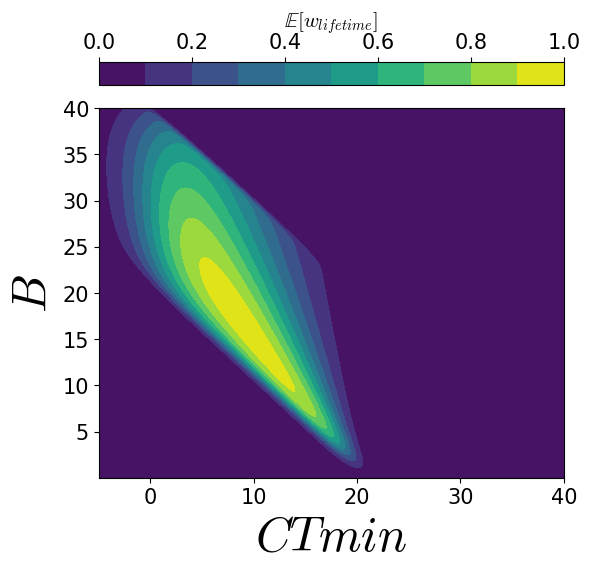

In [ ]:
# Figure 1D
analytical_info = np.load("../data/gaussian_MEAN_TEMP_20_STDEV_TEMP_1_analytical_info.npz", allow_pickle=True)
fig, ax = plt.subplots(figsize=(6, 6))
cm = ax.contourf(analytical_info['CTmin_grid'], analytical_info['B_grid'], analytical_info['W_contour'], 
                 levels=np.linspace(0, 1, 11))
ax.set_xlabel(r"$CTmin$", fontsize=35)
ax.set_ylabel(r"$B$", fontsize=35)
fig.colorbar(cm, ax=ax, label=r'$\mathbb{E}[w_{lifetime}]$', location='top')
fig.savefig("../figures/Fig1d_fitness_landscape.png", bbox_inches='tight')

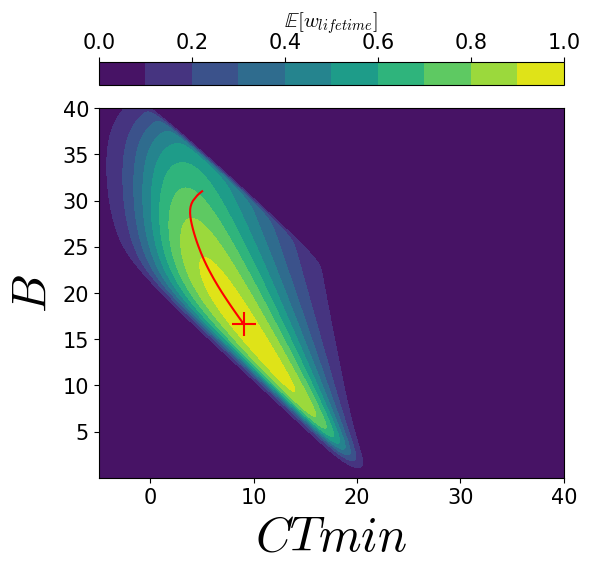

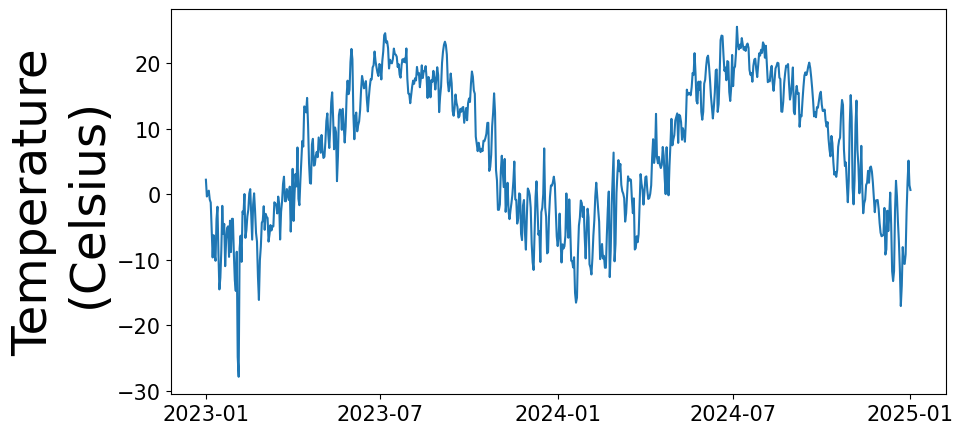

In [ ]:
# Figure 1E
fig, ax = plt.subplots(figsize=(6, 6))
cm = ax.contourf(analytical_info['CTmin_grid'], analytical_info['B_grid'], analytical_info['W_contour'], 
                 levels = np.linspace(0, 1, 11))
ax.plot(analytical_info['sol'].item().y[0], analytical_info['sol'].item().y[1], color='red')
ax.scatter(analytical_info['CTmin_opt'], analytical_info['B_opt'], marker='+', s = 300, color='red')
ax.set_xlabel(r"$CTmin$", fontsize=35)
ax.set_ylabel(r"$B$", fontsize=35)
fig.colorbar(cm, ax=ax, label=r'$\mathbb{E}[w_{lifetime}]$', location='top')
fig.savefig('../figures/Fig1e_trajectory.png', bbox_inches='tight')

VT_temps = pd.read_csv("../slim/VT_weather.txt")

fig, ax = plt.subplots(figsize=(10, 5))

VT_temps["YYYYMMDD"] = pd.to_datetime(VT_temps["YYYYMMDD"])
start_date = pd.Timestamp("2023-01-01")
end_date = pd.Timestamp("2025-01-01")
daily_t2m_vt = VT_temps[(VT_temps["YYYYMMDD"] >= start_date) & (VT_temps["YYYYMMDD"] <= end_date)]

ax.plot(
    daily_t2m_vt["YYYYMMDD"],
    daily_t2m_vt["T2M"],

)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.set_ylabel("Temperature\n(Celsius)", fontsize=35)
fig.savefig("../figures/Fig1e_timeseries.png", bbox_inches='tight')

muT=5, sigmaT=1
muT=5, sigmaT=3
muT=20, sigmaT=1
muT=20, sigmaT=3
muT=35, sigmaT=1
muT=35, sigmaT=3


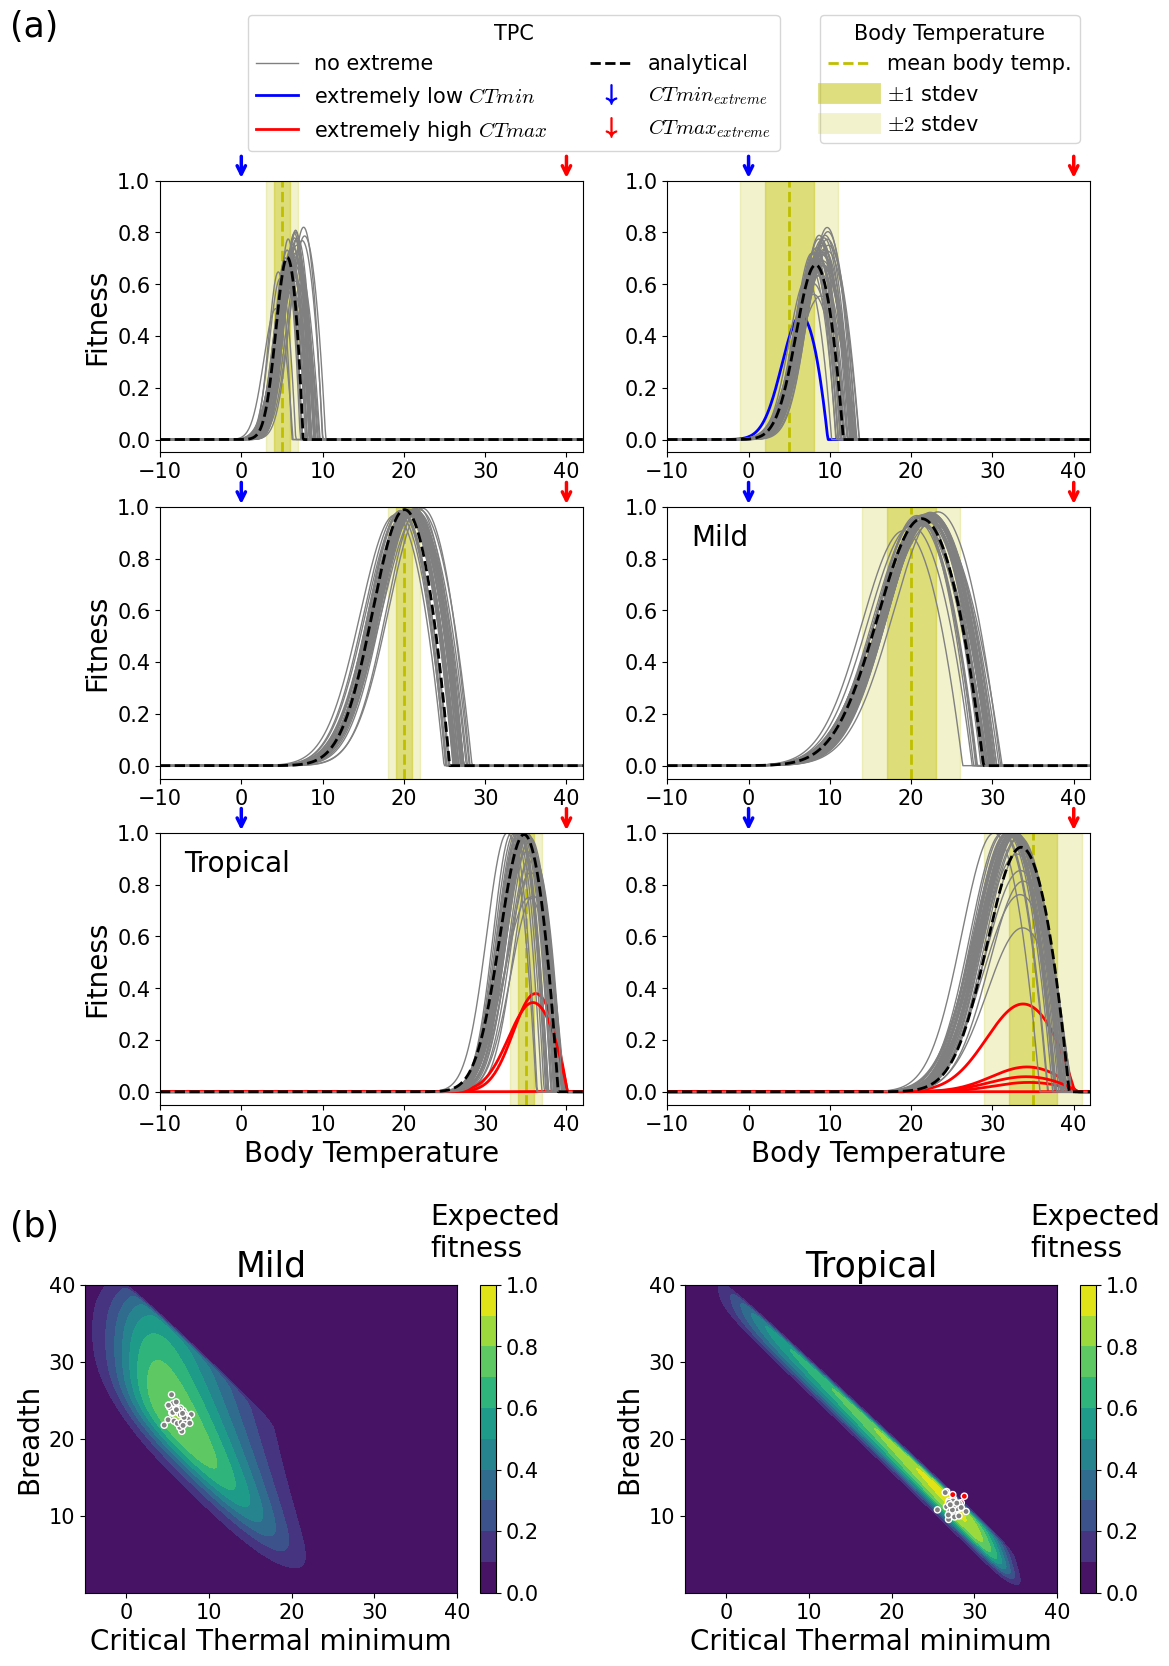

In [ ]:
# Figure 2
plt.rcParams.update({'font.size': 15})
params = pd.read_csv("../scripts/01_prepare_input_parameters/gaussian_params.csv")
params = params[(params.STDEV_TEMP < 10)]
params_sub = params[(params.seed == 29)]
params_sub = params_sub.sort_values(by=['MEAN_TEMP', 'STDEV_TEMP']).reset_index(drop=True)
muTs = params_sub.MEAN_TEMP.unique()
sigmaTs = [1, 3]

fig = plt.figure(figsize=(12, 16))
fig.tight_layout(rect=(0,0,0.7,0.9))


subfigs = fig.subfigures(2, 1, hspace = 0.07, height_ratios=[3,1])
subsubfigs = subfigs[1].subfigures(1, 2, wspace=0.07, width_ratios=[1,1])
subfigs[0].text(0, 1, "(a)", fontsize=25)
subsubfigs[0].text(0, 1, "(b)", fontsize=25)


ax_top = subfigs[0].subplots(nrows = len(muTs), ncols = len(sigmaTs))
T_series = np.linspace(-10, 42, 500)

threshold = 0.5 # threshold for coloring - when the parameter is within critical value
for i, muT in enumerate(muTs):
    for j, sigmaT in enumerate(sigmaTs):
        print(f"muT={muT}, sigmaT={sigmaT}")
        ax_top[i, j].vlines(muT, ymin=-0.05, ymax=1.05, linestyle='--', linewidth=2, color='y')
        ax_top[i, j].axvspan(muT-2*sigmaT, muT+2*sigmaT, color='y', alpha=0.2)
        ax_top[i, j].axvspan(muT-sigmaT, muT+sigmaT, color='y', alpha=0.4)
        ax_top[i, j].set_ylim((-0.05, 1))
        ax_top[i, j].set_xlim((min(T_series), max(T_series)))
        if j == 0:
            ax_top[i,j].set_ylabel(f"Fitness", fontsize=20)
        if i == len(muTs)-1:
            ax_top[i,j].set_xlabel("Body Temperature", fontsize=20)
tropical_Bs= []
tropical_CTmins = []
tropical_colors = []
mild_Bs = []
mild_CTmins = []
mild_colors = []

for index, row in params_sub.iterrows():
    # locate muT and sigmaT in the unique list
    if row.STDEV_TEMP in sigmaTs:
        i = list(muTs).index(row.MEAN_TEMP)
        j = list(sigmaTs).index(row.STDEV_TEMP)
        B_and_CTmin = pd.read_csv(f"{datadir}gaussian_MEAN_TEMP_{row.MEAN_TEMP}_STDEV_TEMP_{row.STDEV_TEMP}_seed_{row.seed}.csv", engine='python', sep=', ')
        Bs_final = np.array(B_and_CTmin.B)
        CTmins_final = np.array(B_and_CTmin.CTmin)
        random.seed(4)
        sample_idx = random.sample(range(len(Bs_final)), 40)
        for B, CTmin in zip(Bs_final[sample_idx], CTmins_final[sample_idx]):
            w_CTmin = tpc_object.w_CTmin(CTmin)
            w_B = tpc_object.w_B(B)
            CTmax = CTmin + B
            w_CTmax = tpc_object.w_CTmax(CTmax)
            if (w_B < threshold) and (w_CTmin > threshold) and (w_CTmax > threshold):
                # Too generalist
                color = 'g'
                linewidth = 2
            elif (w_CTmin < threshold) and (w_B > threshold) and (w_CTmax > threshold):
                # Too much cold adaptation
                color = 'b'
                linewidth = 2
            elif (w_B > threshold) and (w_CTmin > threshold) and (w_CTmax < threshold):
                # Too much heat adaptation
                color = 'r'
                linewidth = 2
            elif (np.array([w_B, w_CTmin, w_CTmax]) > threshold).all():
                # not limited by any of 3 physiological constraints
                color = 'grey'
                linewidth = 1
            else:
                print("constrained by more than one types of limits")
                continue
            ax_top[i, j].plot(T_series, tpc_object.w_TPC(CTmin=CTmin, B=B, T=T_series), 
                        linewidth=linewidth, 
                        color=color)
            # save B, CTmin and color for subfigure (B) and (C) if mild or tropic
            if i == 1 and j == 1:
                mild_Bs.append(B)
                mild_CTmins.append(CTmin)
                mild_colors.append(color)
            elif i == 2 and j == 0:
                tropical_Bs.append(B)
                tropical_CTmins.append(CTmin)
                tropical_colors.append(color)
        analytical_info = np.load(f"{datadir}gaussian_MEAN_TEMP_{row.MEAN_TEMP}_STDEV_TEMP_{row.STDEV_TEMP}_analytical_info.npz", allow_pickle=True)
        ax_top[i,j].plot(T_series, tpc_object.w_TPC(CTmin=analytical_info['CTmin_opt'], B=analytical_info['B_opt'], T=T_series), 
                        linewidth=2, 
                        color='k', 
                        linestyle='--')
        # Blue arrow at T=0 pointing down to the top border (Fitness=1)
        ax_top[i, j].annotate('', xy=(0, 1.0), xytext=(0, 1.1),
                            xycoords=('data', 'axes fraction'),
                            textcoords=('data', 'axes fraction'),
                            annotation_clip=False,
                            arrowprops=dict(arrowstyle='->', color='blue', lw=2.5),
                            clip_on=False)
        # Red arrow at T=40 pointing down to the top border (Fitness=1)
        ax_top[i, j].annotate('', xy=(40, 1.0), xytext=(40, 1.1),
                            xycoords=('data', 'axes fraction'),
                            textcoords=('data', 'axes fraction'),
                            annotation_clip=False,
                            arrowprops=dict(arrowstyle='->', color='red', lw=2.5),
                            clip_on=False)

# Label "tropical" and "mild"
ax_top[2, 0].text(-7, 0.85, "Tropical", fontsize=20)
ax_top[1, 1].text(-7, 0.85, "Mild", fontsize=20)
# Create custom legend handles
legend_handles = [
    Line2D([0], [0], color='grey', linewidth=1, label='no extreme'),
    Line2D([0], [0], color='blue', linewidth=2, label='extremely low $CTmin$'),
    Line2D([0], [0], color='red', linewidth=2, label='extremely high $CTmax$'),
    Line2D([0], [0], color='k', linewidth=2, linestyle='--', label='analytical'),
    Line2D([0], [0], color='blue', linestyle='None', marker=r'$\downarrow$', markersize=14, label='$CTmin_{extreme}$'),
    Line2D([0], [0], color='red', linestyle='None', marker=r'$\downarrow$', markersize=14, label='$CTmax_{extreme}$')]

legend_handles2 = [
    Line2D([0], [0], color='y', linewidth=2, linestyle='--', label='mean body temp.'),
    Line2D([0], [0], color='y', alpha=0.5, linewidth=15, label='$\\pm 1$ stdev'),
    Line2D([0], [0], color='y', alpha=0.2, linewidth=15, label='$\\pm 2$ stdev'), 
]

# Test legend outside the subplots
fig.legend(handles=legend_handles, bbox_to_anchor=(0.65,1.02), ncols=2, title='TPC')
fig.legend(handles=legend_handles2, bbox_to_anchor=(0.9, 1.02), title="Body Temperature")


# Subfigure 2: fitness landscape for tropical vs. mild
ax_bottom_left = subsubfigs[0].subplots(nrows=1, ncols = 1)
analytical_info = np.load(f"{datadir}gaussian_MEAN_TEMP_20_STDEV_TEMP_3_analytical_info.npz", allow_pickle=True)

contour = ax_bottom_left.contourf(analytical_info['CTmin_grid'], 
                                  analytical_info['B_grid'], 
                                  analytical_info['W_contour'], 
                                  levels=np.linspace(0, 1, 11),
                                  cmap='viridis')


ax_bottom_left.set_xlabel("Critical Thermal minimum", fontsize=20)
ax_bottom_left.set_ylabel("Breadth", fontsize=20)
ax_bottom_left.set_title("Mild", fontsize=25)
fig.colorbar(contour, ax=ax_bottom_left)
subsubfigs[0].text(0.7, 0.95, "Expected\nfitness", fontsize=20)
ax_bottom_left.scatter(mild_CTmins, mild_Bs, marker='o', edgecolor='w', facecolor=mild_colors, s=20)

ax_bottom_right = subsubfigs[1].subplots(nrows=1, ncols = 1)

analytical_info = np.load(f"{datadir}gaussian_MEAN_TEMP_35_STDEV_TEMP_1_analytical_info.npz", allow_pickle=True)

contour = ax_bottom_right.contourf(analytical_info['CTmin_grid'], 
                                  analytical_info['B_grid'], 
                                  analytical_info['W_contour'],
                                  levels=np.linspace(0, 1, 11), 
                                  cmap='viridis')
ax_bottom_right.set_xlabel("Critical Thermal minimum", fontsize=20)
ax_bottom_right.set_ylabel("Breadth", fontsize=20)
ax_bottom_right.set_title("Tropical", fontsize=25)
subsubfigs[1].text(0.7, 0.95, "Expected\nfitness", fontsize=20)
fig.colorbar(contour, ax=ax_bottom_right)
ax_bottom_right.scatter(tropical_CTmins, tropical_Bs, marker='o', edgecolor='w', facecolor=tropical_colors, s=20)
fig.savefig('../figures/Fig2_sample_tpcs.pdf', bbox_inches='tight')

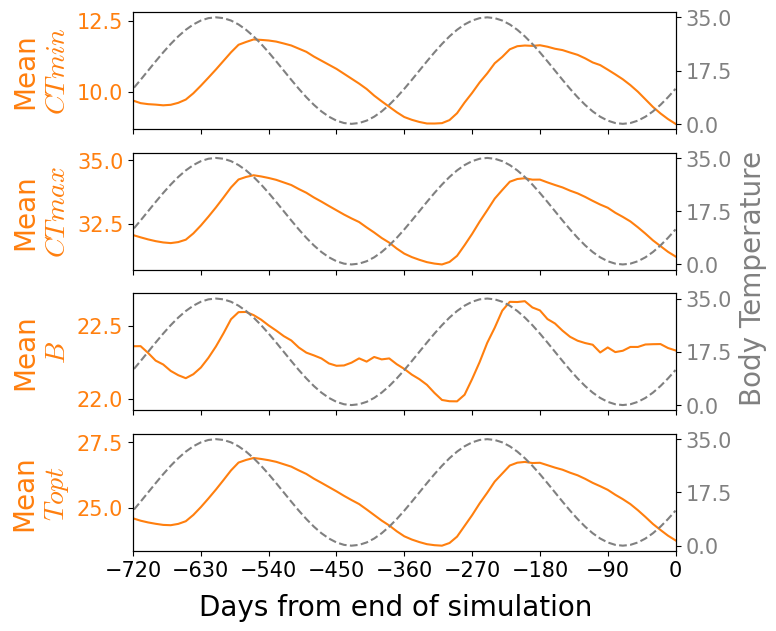

In [ ]:
# Figure 3
CTmin_critical = 0
B_critical = 20
log = pd.read_csv(f"{datadir}sine_test_CTmin_critical_{CTmin_critical}_B_critical_{B_critical}.txt")
# Use only the last 10 years of the data (1 yr = 360 days in this example)
log['day_from_end_of_sim'] = log.day - max(log.day)
log2 = log[log.day_from_end_of_sim > - 3601]

fig, ax = plt.subplots(4, 1, figsize=(7, 7), sharex=True)
ylist = [log2.CTmin_mean, log2.CTmax_mean, log2.B_mean, log2.Topt_mean]
ylabels = [ "Mean\n"+r"$CTmin$", "Mean\n"+r"$CTmax$", "Mean\n"+r"$B$", "Mean\n"+r"$Topt$"]
fig.supxlabel("Days from end of simulation", fontsize=20)
fig.supylabel("Body Temperature", x=1.03, ha='right', va='center', color='grey', fontsize=20)
for i in range(4):
    ax[i].plot(log2.day_from_end_of_sim, ylist[i], color="tab:orange")
    ax[i].set_xlim((-720, 0))
    ax[i].set_xticks(np.arange(-720, 1, 90))
    ax[i].set_ylabel(ylabels[i], color="tab:orange", fontsize=20)
    ax[i].tick_params(axis='y', labelcolor='tab:orange')
    ax2 = ax[i].twinx()
    ax2.plot(log2.day_from_end_of_sim, log2.Temp, color="grey", linestyle="--")
    ax2.set_yticks(np.arange(0, 35.2, 17.5))
    ax2.tick_params(axis='y', labelcolor='grey')

fig.savefig("../figures/Fig3_sinusoidal.pdf", bbox_inches='tight')

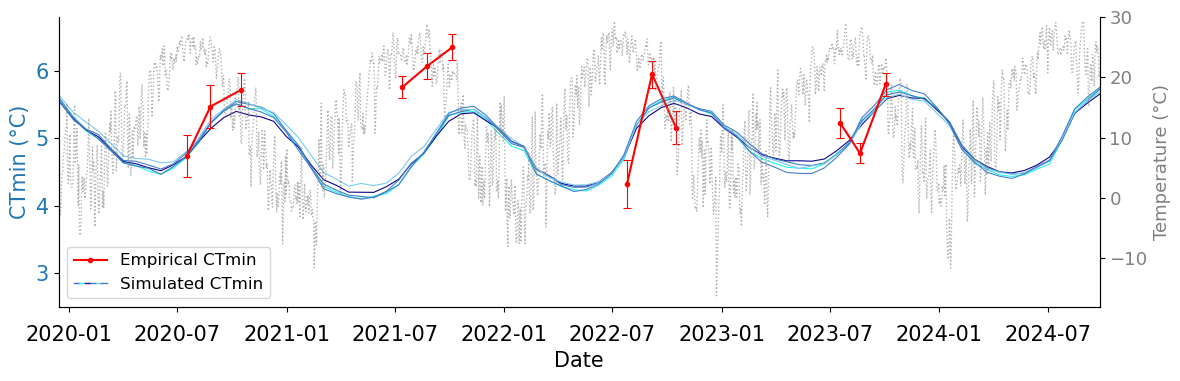

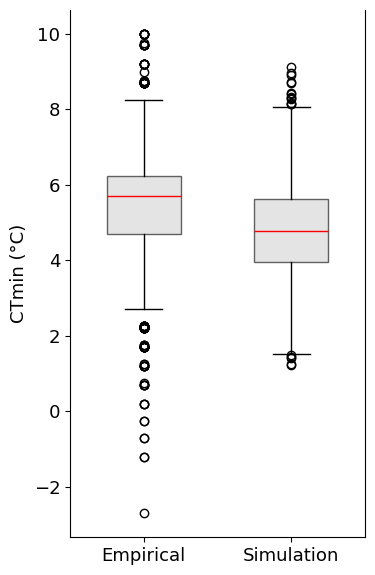

In [ ]:
# Figure 4


# to get trees for boxplot (flexible for names of .trees files)
TP_INFO = {
    'tp1_9':  {'date': '2023-07-19', 'year': 2023, 'timepoint': 'First'},
    'tp2_9':  {'date': '2023-08-21', 'year': 2023, 'timepoint': 'Second'},
    'tp3_9':  {'date': '2023-10-03', 'year': 2023, 'timepoint': 'Third'},
    'tp4_9':  {'date': '2022-07-26', 'year': 2022, 'timepoint': 'First'},
    'tp5_9':  {'date': '2022-09-06', 'year': 2022, 'timepoint': 'Second'},
    'tp6_9':  {'date': '2022-10-16', 'year': 2022, 'timepoint': 'Third'},
    'tp7_9':  {'date': '2021-07-14', 'year': 2021, 'timepoint': 'First'},
    'tp8_9':  {'date': '2021-08-25', 'year': 2021, 'timepoint': 'Second'},
    'tp9_9':  {'date': '2021-10-06', 'year': 2021, 'timepoint': 'Third'},
    'tp10_9': {'date': '2020-07-17', 'year': 2020, 'timepoint': 'First'},
    'tp11_9': {'date': '2020-08-26', 'year': 2020, 'timepoint': 'Second'},
    'tp12_9': {'date': '2020-10-17', 'year': 2020, 'timepoint': 'Third'},
}

# simulation replicates (flexible file path)
SIM_REPLICATES = {
    'rep1': {'file': f'{datadir}/tp1_7.txt', 'color': '#22f5e7'},
    'rep2': {'file': f'{datadir}/tp2_7.txt', 'color': '#0e038a'},
    'rep3': {'file': f'{datadir}/tp3_7.txt', 'color': '#3e7ec7'},
    'rep4': {'file': f'{datadir}/tp4_7.txt', 'color': '#78ccf0'},
    'rep5': {'file': f'{datadir}/tp5_7.txt', 'color': '#477ed1'},
}

PLOT_XLIM = ('2019-12-15', '2024-09-26')
PLOT_YLIM_CTMIN = (2.5, 6.8)
PLOT_YLIM_TEMP  = (-18, 30)
SIM_ROW_SLICE   = slice(20200, 20301) # getting the final simulation CTmins from the four-year empirical window

def load_empirical_ctmin(ctmin_path: str, temp_path):
    """load and aggregate F4-generation empirical CTmin data
    ctmin_path: str (path to empirical CTmin data)
    temp_path: str (path to temperature time series)
    returns: dataframe
    """
    df_temp  = pd.read_csv(temp_path, parse_dates=['YYYYMMDD'])
    df_ctmin = pd.read_csv(ctmin_path).rename(columns={"Year ": "Year"})
    df_ctmin['Collection Date'] = pd.to_datetime(df_ctmin['Collection Date'])

    f4 = df_ctmin[df_ctmin['Generation'] == 'F4 '].copy()
    agg = (
        f4.groupby(['Collection Date', 'Time point'])
          .agg(CTmin_mean=('temp', 'mean'), CTmin_sd=('temp', 'std'), n=('temp', 'count'))
          .reset_index()
          .merge(df_temp[['YYYYMMDD']], left_on='Collection Date', right_on='YYYYMMDD', how='inner')
    )
    agg['Year'] = agg['Collection Date'].dt.year

    result = (
        agg.groupby(['Year', 'Time point'])
           .agg(Collection_Date=('Collection Date', 'first'),
                CTmin_mean=('CTmin_mean', 'mean'),
                CTmin_sd=('CTmin_sd', 'mean'),
                n=('n', 'sum'))
           .reset_index()
    )
    tp_order = ["First", "Second", "Third"]
    result['Time point'] = pd.Categorical(result['Time point'], categories=tp_order, ordered=True)
    result = result.sort_values(['Year', 'Time point']).reset_index(drop=True)
    result['x'] = range(len(result))
    return result, df_temp, f4

def load_replicate(path, real_dates, row_slice: slice = SIM_ROW_SLICE):
    """load a simulation replicate, map sim days to real calendar dates, slice desired window of dates
    path: str (path to simulation replicate file)
    real_dates: series (mapping julien day to real date)
    row_slice: slice (indices corresponding to desired dates)
    returns: dataframe
    """
    df = pd.read_csv(path).sort_values('day').reset_index(drop=True)
    df['sim_day_index'] = df['day'] - df['day'].min()
    df['date'] = df['sim_day_index'].apply(lambda x: real_dates.iloc[x % len(real_dates)])
    return df.iloc[row_slice]

def load_sim_trees(tp_info, data_dir = 'data'):
    """extract CTmin values from all tree files into a df
    tp_info: dict (contains filename and info on sampling timepoint)
    data_dir: str (path to data folder holding tree files)
    returns: dataframe
    """
    records = [
        {'CTmin': val, 'date': info['date'], 'year': info['year'],
         'timepoint': info['timepoint'], 'source': 'Simulation'}
        for tp, info in tp_info.items()
        for val in tskit.load(f"{data_dir}/{tp}.trees")
                        .metadata['SLiM']['user_metadata']['CTmins_final']
    ]
    return pd.DataFrame(records)

class HandlerMultiColorLines(HandlerBase):
    """legend handler that draws a segmented multi-color line"""
    def __init__(self, colors, linewidth=1, **kwargs):
        self.colors, self.linewidth = colors, linewidth
        super().__init__(**kwargs)

    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        n = len(self.colors)
        return [
            Line2D(
                [xdescent + i * width / n, xdescent + (i + 1) * width / n],
                [ydescent + height / 2] * 2,
                color=c, linewidth=self.linewidth, transform=trans
            )
            for i, c in enumerate(self.colors)
        ]

def plot_ctmin_timeseries(f4_ctmin, df_temp, replicates, save_path='ctmin_timeseries.png'):
    """plot empirical + simulated CTmin over time with a temperature background."""
    fig, ax1 = plt.subplots(figsize=(12, 4))
    plt.rcParams.update({'font.size': 13, 'axes.spines.top': False})
    ax1.tick_params(axis='x', pad=10)

    # temperature on right axis
    ax2 = ax1.twinx()
    ax2.plot(df_temp['YYYYMMDD'], df_temp['T2M'],
             color='grey', linestyle='dotted', linewidth=1, alpha=.6, zorder=1)
    ax2.set_ylabel('Temperature (°C)', color='grey')
    ax2.tick_params(axis='y', labelcolor='grey')
    ax2.set_ylim(*PLOT_YLIM_TEMP)
    ax2.spines['top'].set_visible(False)

    # empirical CTmin with +/- 2 se error bars
    for year, g in f4_ctmin.groupby('Year'):
        ax1.errorbar(
            g['Collection_Date'], g['CTmin_mean'],
            yerr=2 * g['CTmin_sd'] / np.sqrt(g['n']),
            color='red', linewidth=1.5, marker='.', linestyle='-',
            elinewidth=0.8, ecolor='red', capsize=3, capthick=0.8, zorder=7,
            label='Empirical CTmin' if year == f4_ctmin['Year'].min() else None
        )

    # simulation replicates
    for rep in replicates.values():
        ax1.plot(rep['df']['date'], rep['df']['CTmin_mean'],
                 color=rep['color'], linewidth=0.8, linestyle='-', zorder=6)

    ax1.spines['top'].set_visible(False)
    ax1.set_ylabel('CTmin (°C)', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.set_ylim(*PLOT_YLIM_CTMIN)
    ax1.set_xlim(pd.to_datetime(PLOT_XLIM[0]), pd.to_datetime(PLOT_XLIM[1]))
    ax1.set_xlabel('Date')

    # legend
    all_colors = ['royalblue'] + [r['color'] for r in replicates.values()]
    sim_handle = Line2D([], [], color='black', linewidth=1, label='Simulated CTmin')
    ax1.legend(
        handles=[Line2D([], [], color='red', marker='.', linestyle='-',
                               linewidth=1.5, label='Empirical CTmin'), sim_handle],
        handler_map={sim_handle: HandlerMultiColorLines(all_colors, linewidth=1)},
        loc='lower left', fontsize=12
    )
    fig.tight_layout()
    plt.savefig(save_path, dpi=300)

def plot_boxplot_comparison(emp_values, sim_values, save_path='boxplot_comparison.png'):
    """side-by-side boxplot of empirical vs simulated CTmin"""
    fig, ax = plt.subplots(figsize=(4, 6))
    plt.rcParams.update({'font.size': 15})
    bp = ax.boxplot(
        [emp_values, sim_values],
        tick_labels=['Empirical', 'Simulation'],
        patch_artist=True,
        medianprops=dict(color='red', linewidth=1),
        widths=0.5
    )
    for box in bp['boxes']:
        box.set_facecolor('lightgrey')
        box.set_alpha(0.6)
    ax.set_ylabel('CTmin (°C)')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)

if __name__ == '__main__':
    # load empirical data
    f4_ctmin, df_temp, df_f4 = load_empirical_ctmin(f'{datadir}/CTminSeasonality.csv', '../slim/KY_timeseries.csv')
    real_dates = df_temp['YYYYMMDD'].reset_index(drop=True)

    # load simulation replicates
    replicates = {
        name: {**cfg, 'df': load_replicate(cfg['file'], real_dates)}
        for name, cfg in SIM_REPLICATES.items()
    }

    # load simulation trees
    sim_df = load_sim_trees(TP_INFO, data_dir=datadir)

    # plots
    plot_ctmin_timeseries(f4_ctmin, df_temp, replicates, save_path='../figures/Fig4-ctmin_timeseries.png')
    plot_boxplot_comparison(df_f4['temp'].values, sim_df['CTmin'].values,
                            save_path='../figures/Fig4-boxplot.png')

In [ ]:
# Save path to all data files needed for this script
datadir = os.path.abspath("../data")
needed = sorted(p for p in _accessed if p.startswith(datadir))
with open("../data/data_for_main_figures.txt", "w") as f:
    f.write("\n".join(os.path.relpath(p, datadir) for p in needed))